# 🤖 Modelagem Preditiva de Evasão de Clientes

Este projeto tem como objetivo desenvolver modelos preditivos capazes de identificar clientes com maior probabilidade de cancelar seus serviços (churn).

A evasão de clientes representa um desafio significativo para empresas de telecomunicações, pois impacta diretamente a receita e o crescimento do negócio.

A partir de técnicas de Machine Learning, buscamos identificar padrões no comportamento dos clientes e compreender quais fatores estão mais associados ao cancelamento.

Nesta etapa iremos construir modelos de machine learning capazes de prever quais clientes possuem maior probabilidade de cancelar seus serviços.

In [ ]:
import pandas as pd

df = pd.read_csv("telecomx_tratado.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,Tempo_Cliente,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Contrato,account.PaperlessBilling,Metodo_Pagamento,Gasto_Mensal,Gasto_Total,Contas_Diarias,Qtd_Servicos
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,3
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,1
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,4
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,2


## Preparação dos dados

Nesta etapa os dados tratados na parte anterior do projeto foram carregados e preparados para utilização em modelos de Machine Learning.

As principais etapas realizadas foram:

- Remoção de colunas irrelevantes para previsão
- Transformação de variáveis categóricas em formato numérico
- Verificação do balanceamento das classes
- Aplicação de técnicas de balanceamento utilizando SMOTE
- Normalização dos dados para modelos baseados em distância

## Remoção de colunas irrelevantes

Colunas como identificadores únicos não contribuem para a previsão da evasão e podem prejudicar o desempenho dos modelos.

In [ ]:
df = df.drop(columns=["customerID"], errors="ignore")

## Transformação de variáveis categóricas

Para utilizar algoritmos de machine learning é necessário transformar variáveis categóricas em valores numéricos.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Churn,customer.SeniorCitizen,Tempo_Cliente,Gasto_Mensal,Gasto_Total,Contas_Diarias,Qtd_Servicos,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,Contrato_One year,Contrato_Two year,account.PaperlessBilling_Yes,Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0.0,0,9,65.6,593.30,2.186667,3,False,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,1.996667,1,True,False,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,2.463333,1,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,3.266667,4,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.40,2.796667,2,False,True,False,...,False,True,False,False,False,False,True,False,False,True


## Balanceamento das classes

Nesta etapa verificamos se existe desequilíbrio entre clientes que cancelaram e clientes que permaneceram.

In [ ]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0.0,0.734215
1.0,0.265785


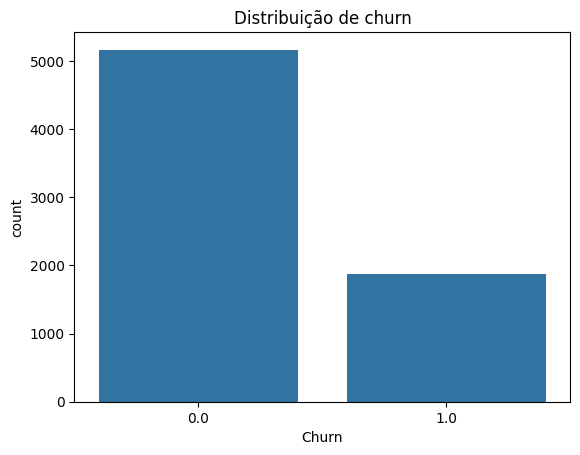

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)

plt.title("Distribuição de churn")

plt.show()

## Balanceamento utilizando SMOTE

Caso exista desequilíbrio entre as classes, podemos utilizar técnicas como SMOTE para gerar exemplos sintéticos da classe minoritária.

In [ ]:
from imblearn.over_sampling import SMOTE

# Remover linhas onde a coluna 'Churn' é NaN
df_cleaned = df.dropna(subset=['Churn'])

X = df_cleaned.drop("Churn", axis=1)
y = df_cleaned["Churn"]

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

## Normalização dos dados

Alguns modelos de machine learning baseados em distância necessitam que os dados estejam na mesma escala.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_res)

## Matriz de correlação

A matriz de correlação permite identificar relações entre variáveis e a evasão de clientes.

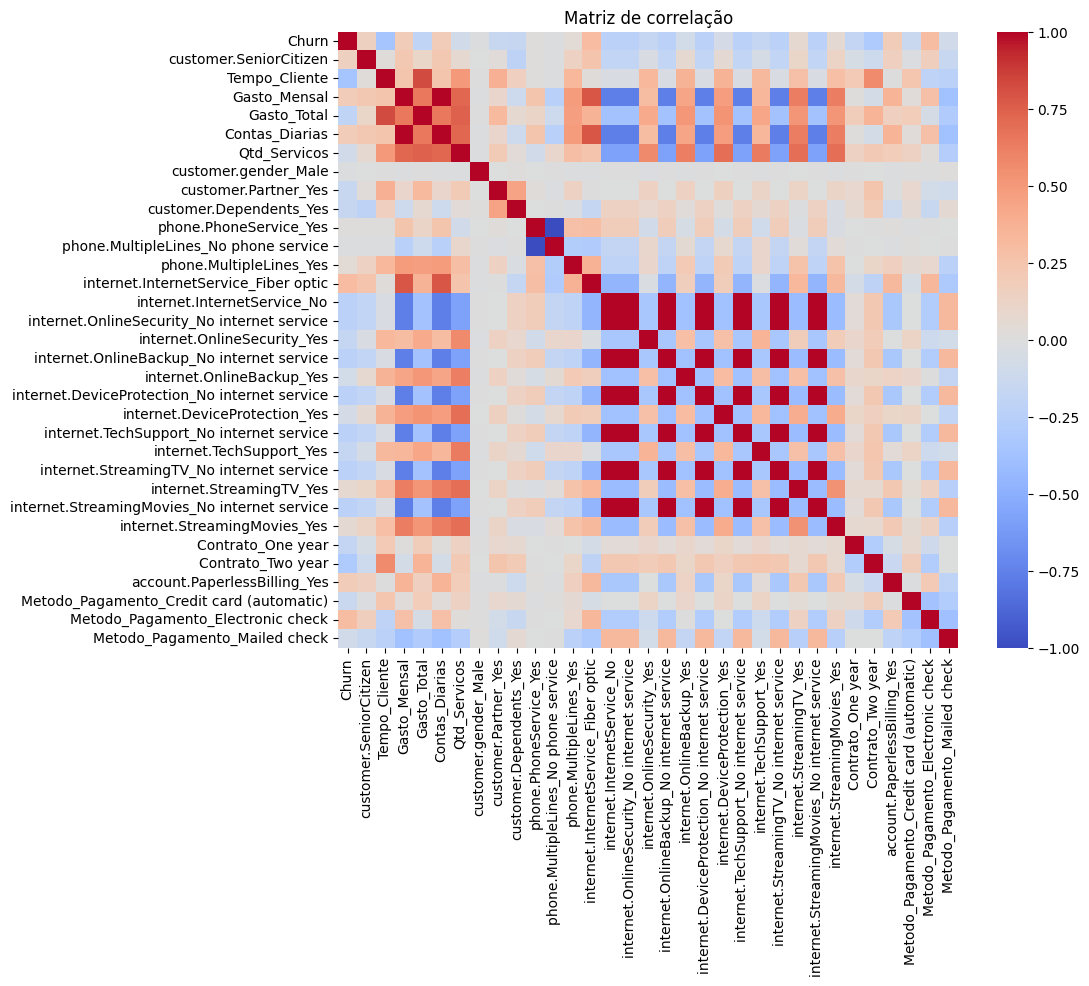

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Matriz de correlação")

plt.show()

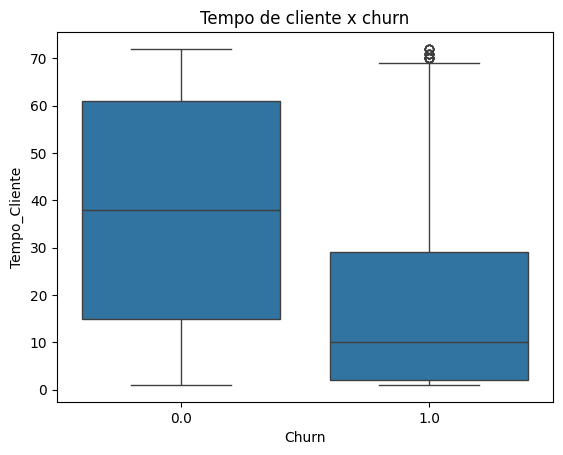

In [ ]:
sns.boxplot(x="Churn", y="Tempo_Cliente", data=df)

plt.title("Tempo de cliente x churn")

plt.show()

## Divisão entre treino e teste

Separação dos dados para treinar o modelo e avaliar sua capacidade de generalização.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_res,
    test_size=0.3,
    random_state=42
)

## Modelo 1 — Regressão Logística

A regressão logística é um modelo simples e interpretável, muito utilizado para problemas de classificação binária.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

pipeline_log.fit(X_train, y_train)

y_pred_log = pipeline_log.predict(X_test)

## Modelo 2 — Random Forest

O Random Forest é um modelo baseado em árvores de decisão que consegue capturar relações complexas entre variáveis.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

[[1347  246]
 [ 236 1269]]
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1593
         1.0       0.84      0.84      0.84      1505

    accuracy                           0.84      3098
   macro avg       0.84      0.84      0.84      3098
weighted avg       0.84      0.84      0.84      3098



In [ ]:
print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

[[1340  253]
 [ 203 1302]]
              precision    recall  f1-score   support

         0.0       0.87      0.84      0.85      1593
         1.0       0.84      0.87      0.85      1505

    accuracy                           0.85      3098
   macro avg       0.85      0.85      0.85      3098
weighted avg       0.85      0.85      0.85      3098



In [ ]:
importances = rf_model.feature_importances_

features = X.columns

importancia = pd.Series(importances, index=features)

importancia.sort_values(ascending=False).head(10)

,0
Tempo_Cliente,0.141076
Gasto_Total,0.136876
Contas_Diarias,0.097116
Gasto_Mensal,0.094418
Metodo_Pagamento_Electronic check,0.088661
internet.InternetService_Fiber optic,0.055041
Qtd_Servicos,0.046711
account.PaperlessBilling_Yes,0.046343
Contrato_Two year,0.033951
customer.gender_Male,0.021439


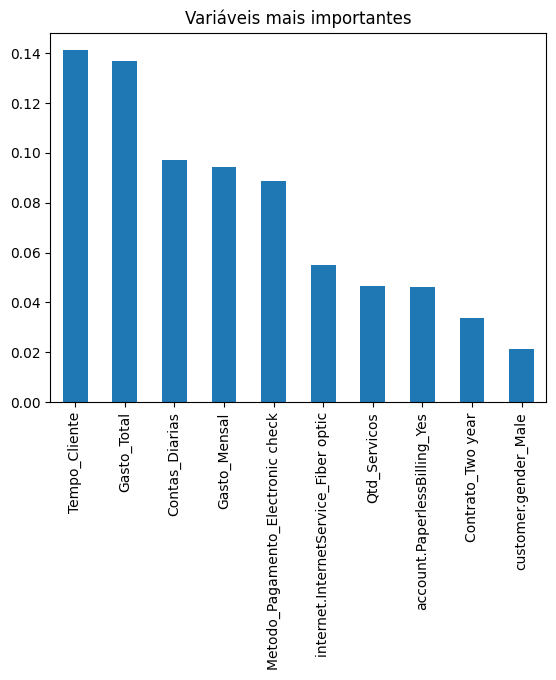

In [ ]:
importancia.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Variáveis mais importantes")

plt.show()

# Conclusão

Os modelos preditivos permitiram identificar fatores importantes relacionados à evasão de clientes.

Entre as variáveis mais relevantes destacam-se o tipo de contrato, o tempo de permanência do cliente e o valor mensal do serviço.

Clientes com contratos mensais e menor tempo de relacionamento apresentam maior probabilidade de cancelar o serviço.

Com base nesses resultados, a empresa pode investir em estratégias de retenção, como incentivos para contratos de longo prazo e melhoria da experiência inicial dos clientes.

---

